### Function

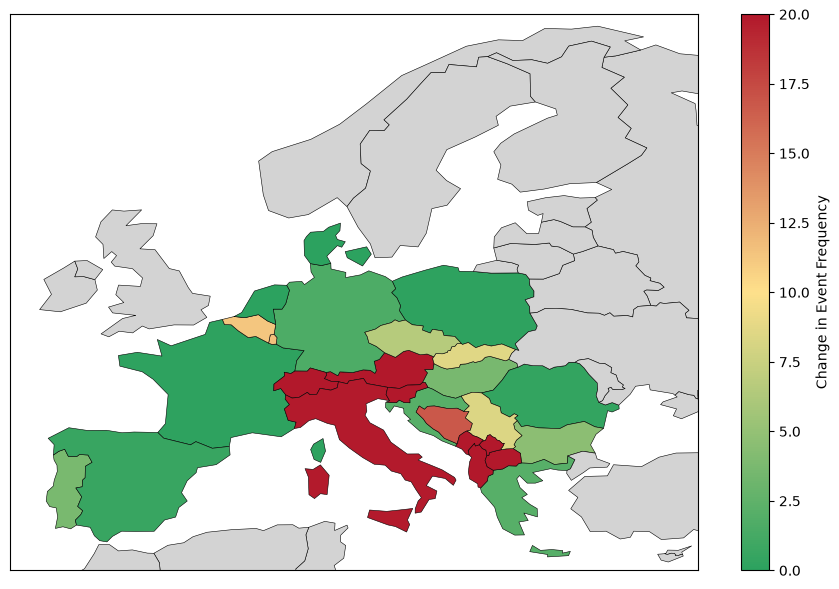

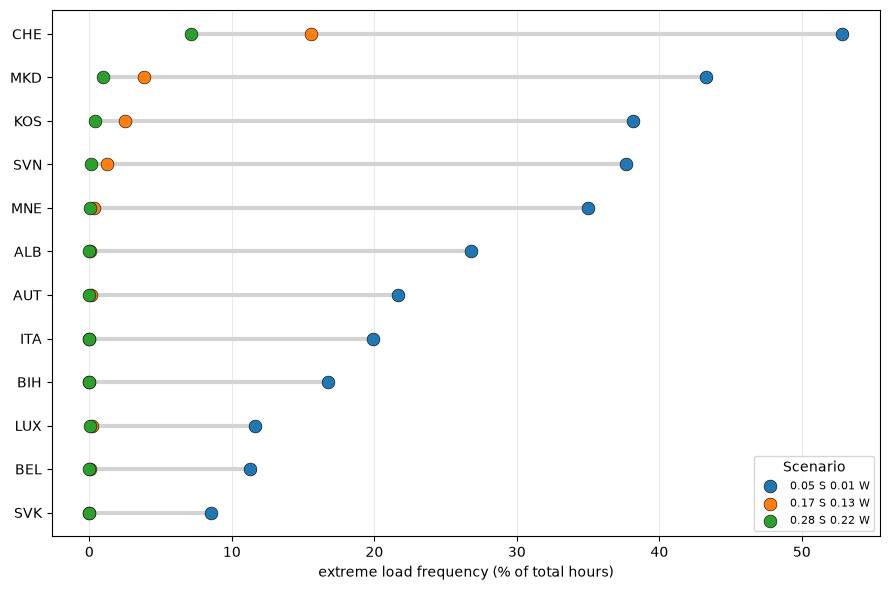

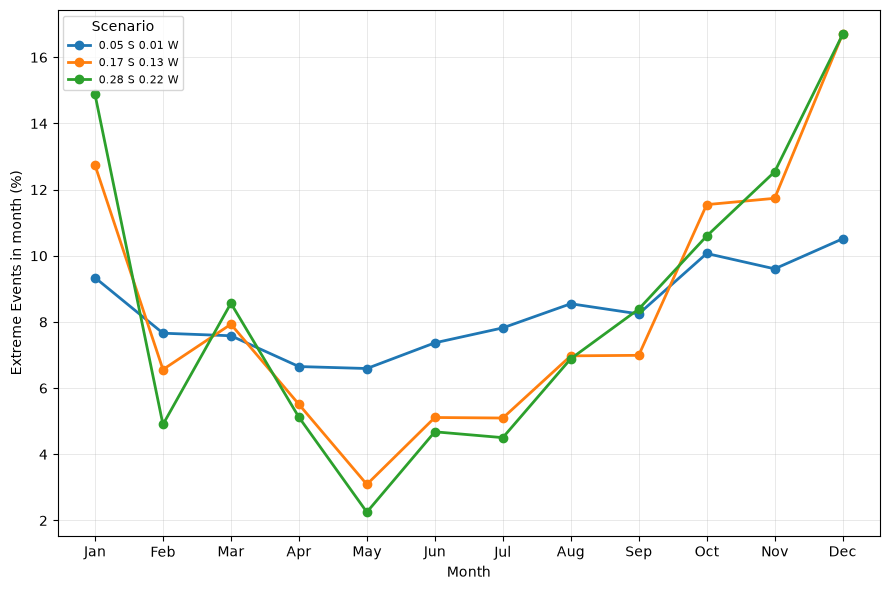

In [ ]:
from pathlib import Path
import calendar

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
import geopandas as gpd


# Config

DATA_PATH = Path("/home/adam/Documents/Imperial/data_science_challenge/datasci-challenge/renewables-dataset.parquet")

STRESS_Q = 0.95

BASELINE_SCENARIO = "0.05 S 0.01 W"
TARGET_SCENARIO = "0.17 S 0.13 W"
TOP_N_COUNTRIES = 12

SCENARIO_COLORS = {"0.05 S 0.01 W": "#1f77b4","0.17 S 0.13 W": "#ff7f0e","0.28 S 0.22 W": "#2ca02c"}


MONTH_LABELS = list(calendar.month_abbr)[1:]

STRESS_CMAP = LinearSegmentedColormap.from_list(
    "stress_green_yellow_red",
    ["#2ca25f", "#fee08b", "#b2182b"])

COUNTRY_CODE_FIXES = {"POR": "PRT","UK": "GBR","GB": "GBR","EL": "GRC","GR": "GRC",}


# Load dataset and manually assign Kosovo

dataset = pd.read_parquet(DATA_PATH)

# Kosovo Correction
d = dataset[(dataset["country"] == "SRB") & (dataset["Time"] == pd.Timestamp("2012-01-01 00:00:00+00:00"))].copy()
kosovo = d[(d["latitude"] < 43)& (d["longitude"] < 21.5)]
kosovo_ID = np.array(kosovo["ID"])
dataset.loc[dataset["ID"].isin(kosovo_ID), "country"] = "KOS"


# Build country-level residual-load dataset

# Getting a dataframe on a country x time level
country_time = pl.from_pandas(dataset).select(["Time", "country", "demand_MWh", "solar_MWh", "wind_MWh"])
country_time = country_time.group_by(["Time", "country"]).agg([
    pl.col("demand_MWh").sum().alias("demand_MWh"), 
    pl.col("solar_MWh").sum().alias("solar_MWh"), 
    pl.col("wind_MWh").sum().alias("wind_MWh")])

# Creating scenarios and joining on data
SCENARIOS = [
    {"scenario": "0.05 S 0.01 W", "a_w": 0.01, "a_s": 0.05, "scenario_order": 1},
    {"scenario": "0.17 S 0.13 W", "a_w": 0.13, "a_s": 0.17, "scenario_order": 2},
    {"scenario": "0.28 S 0.22 W", "a_w": 0.22, "a_s": 0.28, "scenario_order": 3}]

scenario_df = pl.DataFrame(SCENARIOS)
residual = country_time.join(scenario_df, how="cross")

# Calcuating residual and residual/ demand
residual = residual.with_columns([(pl.col("a_s") * pl.col("solar_MWh")).alias("solar_scaled_MWh"), 
                                  (pl.col("a_w") * pl.col("wind_MWh")).alias("wind_scaled_MWh")])
residual =  residual.with_columns([(pl.col("demand_MWh") - pl.col("solar_scaled_MWh") - pl.col("wind_scaled_MWh")).alias("residual_MWh"),
                                    pl.col("Time").dt.month().alias("month")])
residual = residual.with_columns(pl.when(pl.col("demand_MWh") > 0).then(
    pl.col("residual_MWh") / pl.col("demand_MWh")).otherwise(None).alias("residual_over_demand"))


# 1. Create stress threshold

stress_threshold = (residual.select(pl.col("residual_over_demand").drop_nulls().quantile(STRESS_Q)).item())

stress = residual.with_columns((pl.col("residual_over_demand") > stress_threshold).alias("is_stress"))

# 1. Static country map

country_map = (stress.group_by(["country", "scenario", "scenario_order"]).agg([
         (100 * pl.col("is_stress").cast(pl.Float64).mean()).alias("pct_stress_hours")]).sort(
         ["country", "scenario_order"]).group_by("country").agg([
         pl.col("pct_stress_hours").first().alias("stress_2011"),
         pl.col("pct_stress_hours").last().alias("stress_2030")]).with_columns(
         (pl.col("stress_2011") - pl.col("stress_2030")).alias("pct_stress_change")).to_pandas())
country_map["iso_a3"] = country_map["country"].replace(COUNTRY_CODE_FIXES)

world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")
world = world.rename(columns={"ADM0_A3": "iso_a3"})

# Join on the country code and crop the plots
plot_df = world.merge(country_map, on="iso_a3", how="left")
plot_df = plot_df.cx[-25:45, 34:72]

# Plotting countries df
fig, ax = plt.subplots(figsize=(9, 6))
plot_df.plot(column="pct_stress_change", ax=ax, cmap=STRESS_CMAP, edgecolor="black", 
             linewidth=0.4, missing_kwds={"color": "lightgrey"}, legend=True, vmin=0, vmax=20, 
             legend_kwds={"label": "Change in Event Frequency"})

ax.set_xlim(-12, 35)
ax.set_ylim(34, 72)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.savefig("country_map.pdf", bbox_inches="tight")
plt.show()

# 2. Country evolution across scenarios

scenario_freq = (stress.group_by(["country", "scenario", "scenario_order"]).agg(
                (100 * pl.col("is_stress").cast(pl.Float64).mean()).alias("pct_stress_hours")).sort(
                ["country", "scenario_order"]).to_pandas())

# Sort countries by 2011 stress and take the top N
countries = (scenario_freq[scenario_freq["scenario"] == BASELINE_SCENARIO].sort_values("pct_stress_hours", ascending=False).head(TOP_N_COUNTRIES)["country"].tolist())
sensitivity_df = scenario_freq[scenario_freq["country"].isin(countries)].copy()

# Put most-stressed at the top of the plot
country_order = countries[::-1]

fig, ax = plt.subplots(figsize=(9, 6))
ax.set_axisbelow(True)

for y, country in enumerate(country_order):
    sub = sensitivity_df[sensitivity_df["country"] == country].sort_values("scenario_order")
    ax.hlines(y=y, xmin=sub["pct_stress_hours"].min(), xmax=sub["pct_stress_hours"].max(), 
              color="lightgray", linewidth=3, zorder=1)
    for _, row in sub.iterrows():
        ax.scatter(row["pct_stress_hours"], y, s=85, color=SCENARIO_COLORS[row["scenario"]], 
                   edgecolor="black", linewidth=0.4, label=row["scenario"] if y == 0 else None, zorder=3)

ax.set_yticks(np.arange(len(country_order)))
ax.set_yticklabels(country_order)
ax.set_xlabel("extreme load frequency (% of total hours)")
ax.grid(axis="x", linewidth=0.4, alpha=0.5)
ax.legend(title="Scenario", fontsize=8)

plt.tight_layout()
plt.savefig("country_evolution.pdf", bbox_inches="tight")
plt.show()


# 3. Monthly extreme frequency

monthly_stress_rate = (stress.group_by(["scenario", "scenario_order", "month"]).agg(
    pl.col("is_stress").cast(pl.Int64).sum().alias("stress_hours")).with_columns(
        (pl.col("stress_hours") / pl.col("stress_hours").sum().over("scenario")).alias("prop_stress_hours")).sort(["scenario_order", "month"]).to_pandas())
fig, ax = plt.subplots(figsize=(9, 6))

for scenario in SCENARIO_COLORS:
    sub = monthly_stress_rate[monthly_stress_rate["scenario"] == scenario].sort_values("month")
    ax.plot(sub["month"], 100 * sub["prop_stress_hours"], marker="o", linewidth=2, label=scenario, color=SCENARIO_COLORS[scenario])

ax.set_xlabel("Month")
ax.set_ylabel("Extreme Events in month (%)")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_LABELS)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.legend(title="Scenario", fontsize=8)
plt.tight_layout()
plt.savefig("monthly_stress_distribution.pdf", bbox_inches="tight")
plt.show()